In [59]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.signal import butter, filtfilt, medfilt
import imageio.v2 as imageio

try:
    import pywt
    HAS_PYWT = True
except:
    HAS_PYWT = False


# =========================================================
# PATH
# =========================================================
ROOT = Path(r"D:\mmwave-heart-rate-monitoring-demo")

DATA_DIR = ROOT / "data"
ALIGN_DIR = ROOT / "results" / "alignment"
OUT_ROOT = ROOT / "results" / "Heart_estimation_Cepstrum"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

COND_NAMES = [
    "AWR_steady",
    "AWR_unsteady",
    "IWR_steady",
    "IWR_unsteady",
]


# =========================================================
# PARAM
# =========================================================
HR_MIN = 40
HR_MAX = 180

BP_LOW = HR_MIN / 60.0
BP_HIGH = HR_MAX / 60.0

BASE_FILTERS = ["AMP", "BP", "Median", "Wavelet"]

FILTER_COMBOS = [("raw", ())]
for f in BASE_FILTERS:
    FILTER_COMBOS.append((f, (f,)))
for f1 in BASE_FILTERS:
    for f2 in BASE_FILTERS:
        if f1 != f2:
            FILTER_COMBOS.append((f"{f1}->{f2}", (f1, f2)))

CEP_WIN_SEC = 4.0
CEP_HOP_SEC = 0.5
CEP_LIFTER_Q_SEC = 0.10
QUEF_MIN_SEC = 60.0 / HR_MAX
QUEF_MAX_SEC = 60.0 / HR_MIN
EPS = 1e-12

GIF_MAX_FRAMES = 80
GIF_FPS = 3

DEMO_COND = "AWR_steady"
DEMO_SAMPLE = "sample_0"


# =========================================================
# HELPERS
# =========================================================
def sample_key(name):
    m = re.search(r"sample_(\d+)", str(name))
    return int(m.group(1)) if m else 999999


def normalize_pm1(x):
    x = np.asarray(x, dtype=float)
    x = x - np.nanmedian(x)
    m = np.nanmax(np.abs(x))
    if (not np.isfinite(m)) or (m == 0):
        return x
    return x / m


def estimate_fs(t):
    t = np.asarray(t, dtype=float)
    dt = np.diff(t)
    dt = dt[(dt > 0) & np.isfinite(dt)]
    if len(dt) == 0:
        raise ValueError("無法從 time 估計取樣率")
    return 1.0 / np.median(dt)


def parse_seg(seg):
    m = re.match(r"\[(.*),(.*)\]", str(seg))
    if not m:
        return np.nan, np.nan
    return float(m.group(1)), float(m.group(2))


def read_waveform_csv(csv_path: Path):
    if not csv_path.exists():
        raise FileNotFoundError(f"找不到 waveform.csv: {csv_path}")

    df = pd.read_csv(csv_path, comment="#", engine="python")
    df = df.dropna(how="all").copy()

    cols_lower = {c.lower().strip(): c for c in df.columns}

    time_col = None
    for k in ["time", "t", "t_sec", "sec", "seconds"]:
        if k in cols_lower:
            time_col = cols_lower[k]
            break
    if time_col is None:
        raise ValueError(f"{csv_path} 找不到時間欄位")

    value_col = None
    preferred = ["LSB", "lsb", "heartbeat", "value", "signal", "mmwave", "wave"]
    for k in preferred:
        if k in df.columns:
            value_col = k
            break
    if value_col is None:
        for c in df.columns:
            if c != time_col:
                value_col = c
                break
    if value_col is None:
        raise ValueError(f"{csv_path} 找不到訊號欄位")

    out = pd.DataFrame({
        "time": pd.to_numeric(df[time_col], errors="coerce"),
        "signal": pd.to_numeric(df[value_col], errors="coerce"),
    }).dropna().reset_index(drop=True)

    return out


def smooth_track(x, k=3):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    for i in range(len(x)):
        a = max(0, i - k // 2)
        b = min(len(x), i + k // 2 + 1)
        y[i] = np.nanmedian(x[a:b])
    return y

In [60]:
# =========================================================
# FILTERS
# =========================================================
def filter_amp(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return x.copy()
    lo = med - 3 * mad
    hi = med + 3 * mad
    return np.clip(x, lo, hi)


def filter_bp(t, x):
    x = np.asarray(x, dtype=float)
    if len(x) < 10:
        return x.copy()

    try:
        fs = estimate_fs(t)
    except:
        return x.copy()

    if not np.isfinite(fs) or fs <= 0:
        return x.copy()

    nyq = fs / 2.0
    low = BP_LOW / nyq
    high = BP_HIGH / nyq

    if high >= 1:
        high = 0.99
    if low <= 0:
        low = 0.001
    if low >= high:
        return x.copy()

    try:
        b, a = butter(4, [low, high], btype="band")
        return filtfilt(b, a, x)
    except:
        return x.copy()


def filter_median(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 5:
        return x.copy()
    return medfilt(x, 5)


def filter_wavelet(x):
    x = np.asarray(x, dtype=float)
    if not HAS_PYWT:
        return x.copy()

    try:
        coeff = pywt.wavedec(x, "db4", level=4)
        sigma = np.median(np.abs(coeff[-1])) / 0.6745
        uth = sigma * np.sqrt(2 * np.log(len(x)))
        coeff[1:] = [pywt.threshold(c, uth, mode="soft") for c in coeff[1:]]
        y = pywt.waverec(coeff, "db4")
        return y[:len(x)]
    except:
        return x.copy()


def apply_filters(t, x, combo):
    y = np.asarray(x, dtype=float).copy()
    for f in combo:
        if f == "AMP":
            y = filter_amp(y)
        elif f == "BP":
            y = filter_bp(t, y)
        elif f == "Median":
            y = filter_median(y)
        elif f == "Wavelet":
            y = filter_wavelet(y)
    return y


# =========================================================
# CEPSTRUM
# =========================================================
def single_window_cepstrum_from_segment(seg_x, fs, lifter_q_sec=CEP_LIFTER_Q_SEC, hr_min=HR_MIN, hr_max=HR_MAX, eps=EPS):
    seg_x = np.asarray(seg_x, dtype=float)
    seg_x = seg_x - np.mean(seg_x)

    nfft = int(2 ** np.ceil(np.log2(max(16, len(seg_x) * 8))))
    q_axis = np.arange(nfft) / fs

    q_min = 60.0 / hr_max
    q_max = 60.0 / hr_min

    w = signal.windows.hann(len(seg_x), sym=False)
    X = np.fft.rfft(seg_x * w, n=nfft)
    L = np.log(np.maximum(np.abs(X), eps))
    c = np.real(np.fft.irfft(L, n=nfft))

    c_lift = c.copy()
    c_lift[q_axis < lifter_q_sec] = 0.0

    mask_q = (q_axis >= max(q_min, lifter_q_sec)) & (q_axis <= q_max)
    c_pick = np.where(mask_q, c_lift, -np.inf)
    pk_idx = int(np.argmax(c_pick))
    q_pk = q_axis[pk_idx]
    hr_pk = 60.0 / q_pk if q_pk > 0 else np.nan

    return {
        "q_axis_sec": q_axis,
        "cepstrum": c,
        "cepstrum_lifted": c_lift,
        "q_peak_sec": q_pk,
        "hr_peak_bpm": hr_pk,
    }


def sliding_cepstrum_hr(
    t,
    x,
    hr_min=HR_MIN,
    hr_max=HR_MAX,
    win_sec=CEP_WIN_SEC,
    hop_sec=CEP_HOP_SEC,
    lifter_q_sec=CEP_LIFTER_Q_SEC,
    eps=EPS,
):
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)

    if len(t) < 10 or len(x) < 10:
        return None

    fs = estimate_fs(t)
    N = len(x)

    win_len = int(round(win_sec * fs))
    hop_len = int(round(hop_sec * fs))

    if win_len < 8:
        return None
    if hop_len < 1:
        hop_len = 1
    if win_len > N:
        win_len = N

    x = x - np.nanmean(x)

    q_min = 60.0 / hr_max
    q_max = 60.0 / hr_min

    nfft_win = int(2 ** np.ceil(np.log2(max(16, win_len))))
    q_axis = np.arange(nfft_win) / fs

    mask_q = (q_axis >= max(q_min, lifter_q_sec)) & (q_axis <= q_max)
    if np.sum(mask_q) < 3:
        return None

    w = signal.windows.hann(win_len, sym=False)

    centers = []
    start_idx_list = []
    end_idx_list = []
    q_peaks = []
    hr_track = []
    cep_frames = []

    for start in range(0, max(1, N - win_len + 1), hop_len):
        seg = x[start:start + win_len]
        if len(seg) < win_len:
            break

        seg = seg - np.mean(seg)

        Xw = np.fft.rfft(seg * w, n=nfft_win)
        Lw = np.log(np.maximum(np.abs(Xw), eps))
        c = np.real(np.fft.irfft(Lw, n=nfft_win))

        c = c.copy()
        c[q_axis < lifter_q_sec] = 0.0

        c_pick = np.where(mask_q, c, -np.inf)
        pk_idx = int(np.argmax(c_pick))
        q_pk = q_axis[pk_idx]
        hr = 60.0 / q_pk if np.isfinite(q_pk) and q_pk > 0 else np.nan

        centers.append(t[min(start + win_len // 2, N - 1)])
        start_idx_list.append(start)
        end_idx_list.append(start + win_len)
        q_peaks.append(q_pk)
        hr_track.append(hr)
        cep_frames.append(c)

    if len(cep_frames) == 0:
        return None

    return {
        "fs": fs,
        "centers_sec": np.asarray(centers),
        "start_idx_list": np.asarray(start_idx_list),
        "end_idx_list": np.asarray(end_idx_list),
        "q_peak_track_sec": np.asarray(q_peaks),
        "hr_track_bpm": np.asarray(hr_track, dtype=float),
        "q_axis_sec": q_axis,
        "cepstrogram": np.stack(cep_frames, axis=1),
        "hr_summary_bpm": float(np.nanmedian(hr_track)),
        "win_sec": win_sec,
        "hop_sec": hop_sec,
        "lifter_q_sec": lifter_q_sec,
    }


def get_single_window_from_result(t, x, cep_result, frame_idx=None):
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)

    if frame_idx is None:
        frame_idx = len(cep_result["centers_sec"]) // 2

    s = int(cep_result["start_idx_list"][frame_idx])
    e = int(cep_result["end_idx_list"][frame_idx])

    seg_x = x[s:e]
    one = single_window_cepstrum_from_segment(seg_x, cep_result["fs"])
    one["start_idx"] = s
    one["end_idx"] = e
    one["seg_t"] = t[s:e]
    one["seg_x"] = seg_x
    return one

In [61]:
# =========================================================
# PLOT
# =========================================================
def plot_sliding_window_demo(t, x, cep_one, out_png=None, title="Sliding window + cepstrum"):
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 6),
        gridspec_kw={"height_ratios": [1, 2]},
        constrained_layout=False
    )

    q_axis = cep_one["q_axis_sec"]
    c = cep_one["cepstrum"]
    c_lift = cep_one["cepstrum_lifted"]
    q_pk = cep_one["q_peak_sec"]

    mask = (q_axis >= QUEF_MIN_SEC) & (q_axis <= QUEF_MAX_SEC)

    ax1.plot(q_axis[mask], c[mask], label="Cepstrum", linewidth=2)
    ax1.plot(q_axis[mask], c_lift[mask], label="Lifted", linewidth=2, alpha=0.9)
    ax1.axvline(q_pk, linestyle="--", linewidth=2)

    ax1.set_xlim(QUEF_MIN_SEC, QUEF_MAX_SEC)
    ax1.set_ylabel("Amplitude")
    ax1.set_title(
        f"{title}\nPeak quefrency = {q_pk:.3f} s, HR = {cep_one['hr_peak_bpm']:.2f} bpm",
        pad=10
    )
    ax1.legend(loc="upper left")
    ax1.set_xlabel("")

    x_plot = normalize_pm1(x)
    ax2.plot(t, x_plot, linewidth=1.6)

    s = cep_one["start_idx"]
    e = cep_one["end_idx"]
    ax2.axvspan(t[s], t[e - 1], alpha=0.25, color="orange")

    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Normalized Signal")
    ax2.set_title("Signal with highlighted sliding window", pad=10)

    fig.subplots_adjust(hspace=0.45)

    if out_png is not None:
        fig.savefig(out_png, dpi=220, bbox_inches="tight")

    plt.show()


def plot_cepstrogram(result, out_png=None, title="Cepstrogram heatmap", smooth_k=3):
    q_axis = result["q_axis_sec"]
    t_axis = result["centers_sec"]
    C = result["cepstrogram"]
    q_peak = np.asarray(result["q_peak_track_sec"], dtype=float)

    mask_q = (q_axis >= QUEF_MIN_SEC) & (q_axis <= QUEF_MAX_SEC)
    q_show = q_axis[mask_q]
    C_show = C[mask_q, :]

    C_shift = C_show - np.nanmin(C_show)
    C_db = 20 * np.log10(np.maximum(C_shift, 1e-8))
    C_db = C_db - np.nanmax(C_db)

    vmin = np.nanpercentile(C_db, 5)
    vmax = np.nanpercentile(C_db, 99)

    q_peak_smooth = smooth_track(q_peak, k=smooth_k)
    valid = np.isfinite(q_peak_smooth) & (q_peak_smooth >= QUEF_MIN_SEC) & (q_peak_smooth <= QUEF_MAX_SEC)

    fig, ax = plt.subplots(figsize=(12, 5))

    im = ax.imshow(
        C_db,
        aspect="auto",
        origin="lower",
        extent=[t_axis[0], t_axis[-1], q_show[0], q_show[-1]],
        interpolation="bilinear",
        vmin=vmin,
        vmax=vmax,
    )

    ax.plot(t_axis[valid], q_peak_smooth[valid], color="red", linewidth=1.6, alpha=0.9)
    ax.scatter(t_axis[valid], q_peak_smooth[valid], color="red", s=10, alpha=0.9)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Quefrency (s)")
    ax.set_title(f"{title}\nHR median = {result['hr_summary_bpm']:.2f} bpm")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Cepstrum Power (dB)")

    if out_png is not None:
        fig.savefig(out_png, dpi=220, bbox_inches="tight")

    plt.show()


# =========================================================
# GIF
# =========================================================
def make_sliding_window_gif(t, x, cep_result, out_gif, title="", max_frames=GIF_MAX_FRAMES, fps=GIF_FPS):
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)

    n_frames_total = len(cep_result["centers_sec"])
    if n_frames_total == 0:
        return

    if n_frames_total <= max_frames:
        use_idx = np.arange(n_frames_total)
    else:
        use_idx = np.linspace(0, n_frames_total - 1, max_frames).astype(int)

    tmp_dir = out_gif.parent / "_tmp_gif_frames"
    tmp_dir.mkdir(parents=True, exist_ok=True)

    frame_paths = []

    for k, idx in enumerate(use_idx):
        one = get_single_window_from_result(t, x, cep_result, frame_idx=int(idx))

        fig, (ax1, ax2) = plt.subplots(
            2, 1,
            figsize=(10, 6),
            gridspec_kw={"height_ratios": [1, 2]},
            constrained_layout=False
        )

        q_axis = one["q_axis_sec"]
        c = one["cepstrum"]
        c_lift = one["cepstrum_lifted"]
        q_pk = one["q_peak_sec"]

        mask = (q_axis >= QUEF_MIN_SEC) & (q_axis <= QUEF_MAX_SEC)

        ax1.plot(q_axis[mask], c[mask], linewidth=2, label="Cepstrum")
        ax1.plot(q_axis[mask], c_lift[mask], linewidth=2, alpha=0.9, label="Lifted")
        ax1.axvline(q_pk, linestyle="--", linewidth=2)
        ax1.set_xlim(QUEF_MIN_SEC, QUEF_MAX_SEC)
        ax1.set_ylabel("Amplitude")
        ax1.set_title(f"{title}\nframe={idx} | q={q_pk:.3f}s | HR={one['hr_peak_bpm']:.2f} bpm")
        ax1.legend(loc="upper left")

        ax2.plot(t, normalize_pm1(x), linewidth=1.5)
        s = one["start_idx"]
        e = one["end_idx"]
        ax2.axvspan(t[s], t[e - 1], alpha=0.25, color="orange")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Normalized Signal")
        ax2.set_title("Sliding window movement")

        fig.subplots_adjust(hspace=0.45)

        frame_path = tmp_dir / f"frame_{k:04d}.png"
        fig.savefig(frame_path, dpi=140)
        plt.close(fig)

        frame_paths.append(frame_path)

    images = [imageio.imread(fp) for fp in frame_paths]
    imageio.mimsave(out_gif, images, fps=fps)

    for fp in frame_paths:
        try:
            fp.unlink()
        except:
            pass

    try:
        tmp_dir.rmdir()
    except:
        pass

In [62]:
# =========================================================
# PLOT
# =========================================================
def plot_cepstrogram(result, out_png=None, title="Cepstrogram heatmap", smooth_k=3, show_plot=True):
    q_axis = result["q_axis_sec"]
    t_axis = result["centers_sec"]
    C = result["cepstrogram"]
    q_peak = np.asarray(result["q_peak_track_sec"], dtype=float)

    mask_q = (q_axis >= QUEF_MIN_SEC) & (q_axis <= QUEF_MAX_SEC)
    q_show = q_axis[mask_q]
    C_show = C[mask_q, :]

    C_shift = C_show - np.nanmin(C_show)
    C_db = 20 * np.log10(np.maximum(C_shift, 1e-8))
    C_db = C_db - np.nanmax(C_db)

    vmin = np.nanpercentile(C_db, 5)
    vmax = np.nanpercentile(C_db, 99)

    q_peak_smooth = smooth_track(q_peak, k=smooth_k)
    valid = np.isfinite(q_peak_smooth) & (q_peak_smooth >= QUEF_MIN_SEC) & (q_peak_smooth <= QUEF_MAX_SEC)

    fig, ax = plt.subplots(figsize=(12, 5))

    im = ax.imshow(
        C_db,
        aspect="auto",
        origin="lower",
        extent=[t_axis[0], t_axis[-1], q_show[0], q_show[-1]],
        interpolation="bilinear",
        vmin=vmin,
        vmax=vmax,
    )

    ax.plot(t_axis[valid], q_peak_smooth[valid], color="red", linewidth=1.6, alpha=0.9)
    ax.scatter(t_axis[valid], q_peak_smooth[valid], color="red", s=10, alpha=0.9)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Quefrency (s)")
    ax.set_title(f"{title}\nHR median = {result['hr_summary_bpm']:.2f} bpm")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Cepstrum Power (dB)")

    if out_png is not None:
        fig.savefig(out_png, dpi=220, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

# =========================================================
# GIF
# =========================================================
def make_sliding_window_gif(t, x, cep_result, out_gif, title="", max_frames=GIF_MAX_FRAMES, fps=GIF_FPS):
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)

    n_frames_total = len(cep_result["centers_sec"])
    if n_frames_total == 0:
        return

    if n_frames_total <= max_frames:
        use_idx = np.arange(n_frames_total)
    else:
        use_idx = np.linspace(0, n_frames_total - 1, max_frames).astype(int)

    tmp_dir = out_gif.parent / "_tmp_gif_frames"
    tmp_dir.mkdir(parents=True, exist_ok=True)

    frame_paths = []

    for k, idx in enumerate(use_idx):
        one = get_single_window_from_result(t, x, cep_result, frame_idx=int(idx))

        fig, (ax1, ax2) = plt.subplots(
            2, 1,
            figsize=(10, 6),
            gridspec_kw={"height_ratios": [1, 2]},
            constrained_layout=False
        )

        q_axis = one["q_axis_sec"]
        c = one["cepstrum"]
        c_lift = one["cepstrum_lifted"]
        q_pk = one["q_peak_sec"]

        mask = (q_axis >= QUEF_MIN_SEC) & (q_axis <= QUEF_MAX_SEC)

        ax1.plot(q_axis[mask], c[mask], linewidth=2, label="Cepstrum")
        ax1.plot(q_axis[mask], c_lift[mask], linewidth=2, alpha=0.9, label="Lifted")
        ax1.axvline(q_pk, linestyle="--", linewidth=2)
        ax1.set_xlim(QUEF_MIN_SEC, QUEF_MAX_SEC)
        ax1.set_ylabel("Amplitude")
        ax1.set_title(f"{title}\nframe={idx} | q={q_pk:.3f}s | HR={one['hr_peak_bpm']:.2f} bpm")
        ax1.legend(loc="upper left")

        ax2.plot(t, normalize_pm1(x), linewidth=1.5)
        s = one["start_idx"]
        e = one["end_idx"]
        ax2.axvspan(t[s], t[e - 1], alpha=0.25, color="orange")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Normalized Signal")
        ax2.set_title("Sliding window movement")

        fig.subplots_adjust(hspace=0.45)

        frame_path = tmp_dir / f"frame_{k:04d}.png"
        fig.savefig(frame_path, dpi=140)
        plt.close(fig)

        frame_paths.append(frame_path)

    images = [imageio.imread(fp) for fp in frame_paths]
    imageio.mimsave(out_gif, images, fps=fps)

    for fp in frame_paths:
        try:
            fp.unlink()
        except:
            pass
    try:
        tmp_dir.rmdir()
    except:
        pass

sample = sample_0
ECG_HR = 58.0
best combo = raw
best cep HR = 60.00000000000021
best error = 2.000000000000213


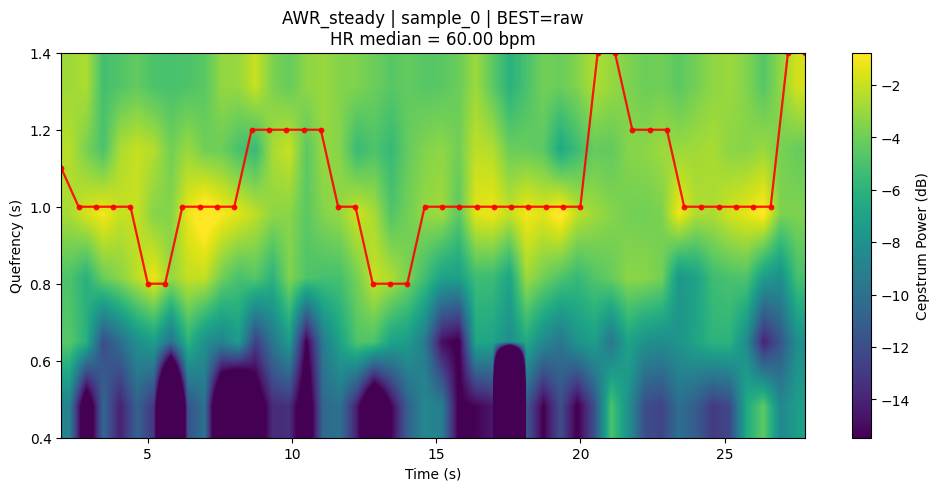

In [63]:
def run_one_sample_all_combos(cond, sample_name):
    align_csv = ALIGN_DIR / f"{cond}.csv"
    df_align = pd.read_csv(align_csv)

    row = df_align[df_align["sample_name"] == sample_name]
    if len(row) == 0:
        raise ValueError(f"{cond} 找不到 {sample_name}")
    row = row.iloc[0]

    start, end = parse_seg(row["seg_drscc"])

    wave_csv = DATA_DIR / cond / sample_name / "waveform.csv"
    raw = read_waveform_csv(wave_csv)

    t_all = raw["time"].values.astype(float)
    x_all = raw["signal"].values.astype(float)

    mask = (t_all >= start) & (t_all < end)
    t = t_all[mask]
    x = x_all[mask]

    if len(t) < 10:
        raise ValueError("切出來的訊號太短")

    t = t - t[0]
    results = []

    for combo_name, combo in FILTER_COMBOS:
        try:
            y = x.copy() if combo_name == "raw" else apply_filters(t, x, combo)
            cep = sliding_cepstrum_hr(t, y)

            hr = np.nan if cep is None else cep["hr_summary_bpm"]
            err = hr - row["ECG_HR"] if np.isfinite(hr) and np.isfinite(row["ECG_HR"]) else np.nan
            abs_err = abs(err) if np.isfinite(err) else np.nan

            results.append({
                "combo_name": combo_name,
                "filtered_signal": y,
                "cep_result": cep,
                "CEP_HR": hr,
                "ERR": err,
                "ABS_ERR": abs_err,
            })
        except:
            results.append({
                "combo_name": combo_name,
                "filtered_signal": None,
                "cep_result": None,
                "CEP_HR": np.nan,
                "ERR": np.nan,
                "ABS_ERR": np.nan,
            })

    res_df = pd.DataFrame([{
        "combo_name": r["combo_name"],
        "CEP_HR": r["CEP_HR"],
        "ERR": r["ERR"],
        "ABS_ERR": r["ABS_ERR"],
    } for r in results]).sort_values("ABS_ERR", na_position="last").reset_index(drop=True)

    best_name = res_df.iloc[0]["combo_name"]
    best_obj = next(r for r in results if r["combo_name"] == best_name)

    return {
        "cond": cond,
        "sample_name": sample_name,
        "ECG_HR": row["ECG_HR"],
        "mmw_HR_drscc": row["mmw_HR_drscc"],
        "seg_drscc": row["seg_drscc"],
        "t": t,
        "x_raw": x,
        "result_table": res_df,
        "best_name": best_name,
        "best_signal": best_obj["filtered_signal"],
        "best_cep": best_obj["cep_result"],
        "best_hr": best_obj["CEP_HR"],
        "best_err": best_obj["ERR"],
    }

if __name__ == "__main__":
    demo = run_one_sample_all_combos(DEMO_COND, DEMO_SAMPLE)
    print("sample =", demo["sample_name"])
    print("ECG_HR =", demo["ECG_HR"])
    print("best combo =", demo["best_name"])
    print("best cep HR =", demo["best_hr"])
    print("best error =", demo["best_err"])

    plot_cepstrogram(
        demo["best_cep"],
        title=f"{demo['cond']} | {demo['sample_name']} | BEST={demo['best_name']}",
        show_plot=True
    )

    make_sliding_window_gif(
        demo["t"],
        demo["best_signal"],
        demo["best_cep"],
        out_gif=OUT_ROOT / "demo.gif",
        title=f"{demo['cond']} | {demo['sample_name']} | BEST={demo['best_name']}"
    )

In [ ]:
for cond in COND_NAMES:
    print("\n===================================")
    print("Processing:", cond)
    print("===================================")

    align_csv = ALIGN_DIR / f"{cond}.csv"
    df_align = pd.read_csv(align_csv).copy()

    keep_cols = ["sample_name", "ECG_HR", "seg_drscc", "mmw_HR_drscc"]
    df_align = df_align[keep_cols].copy()
    df_align["start"], df_align["end"] = zip(*df_align["seg_drscc"].map(parse_seg))
    df_align = df_align.sort_values("sample_name", key=lambda s: s.map(sample_key)).reset_index(drop=True)

    summary_rows = []

    for i, row in df_align.iterrows():
        sample_name = row["sample_name"]
        print(f"[{i+1}/{len(df_align)}] {sample_name}")

        sample_dir = DATA_DIR / cond / sample_name
        wave_csv = sample_dir / "waveform.csv"
        sample_out_dir = sample_dir / "Heart_estimation_Cepstrum"
        sample_out_dir.mkdir(parents=True, exist_ok=True)

        # 先建立這個 sample 的 summary row
        row_out = {
            "sample_name": sample_name,
            "ECG_HR": row["ECG_HR"],
            "seg_drscc": row["seg_drscc"],
            "mmw_HR_drscc": row["mmw_HR_drscc"],
        }

        # 先把所有 filter HR 欄位建出來
        for combo_name, _ in FILTER_COMBOS:
            row_out[f"{combo_name}_CEP_HR"] = np.nan

        row_out["best_filter"] = ""

        if not wave_csv.exists():
            print("  waveform.csv not found")
            summary_rows.append(row_out)
            continue

        try:
            raw = read_waveform_csv(wave_csv)
            t_all = raw["time"].values.astype(float)
            x_all = raw["signal"].values.astype(float)

            mask = (t_all >= row["start"]) & (t_all < row["end"])
            t = t_all[mask]
            x = x_all[mask]

            if len(t) < 10:
                raise ValueError("segment too short")

            t = t - t[0]

            combo_records = []

            for combo_name, combo in FILTER_COMBOS:
                try:
                    y = x.copy() if combo_name == "raw" else apply_filters(t, x, combo)
                    cep = sliding_cepstrum_hr(t, y)
                    hr = np.nan if cep is None else cep["hr_summary_bpm"]

                    # 存進 csv 欄位
                    row_out[f"{combo_name}_CEP_HR"] = hr

                    # 只用來選最佳，不寫進 csv
                    err = hr - row["ECG_HR"] if np.isfinite(hr) and np.isfinite(row["ECG_HR"]) else np.nan
                    abs_err = abs(err) if np.isfinite(err) else np.nan

                    combo_records.append({
                        "combo_name": combo_name,
                        "filtered_signal": y,
                        "cep_result": cep,
                        "CEP_HR": hr,
                        "ERR": err,
                        "ABS_ERR": abs_err,
                    })

                except Exception:
                    row_out[f"{combo_name}_CEP_HR"] = np.nan
                    combo_records.append({
                        "combo_name": combo_name,
                        "filtered_signal": None,
                        "cep_result": None,
                        "CEP_HR": np.nan,
                        "ERR": np.nan,
                        "ABS_ERR": np.nan,
                    })

            # 用誤差最小選最佳，但不把 ERR / ABS_ERR 寫進 csv
            combo_df = pd.DataFrame([{
                "combo_name": r["combo_name"],
                "CEP_HR": r["CEP_HR"],
                "ERR": r["ERR"],
                "ABS_ERR": r["ABS_ERR"],
            } for r in combo_records]).sort_values("ABS_ERR", na_position="last").reset_index(drop=True)

            if len(combo_df) > 0 and pd.notna(combo_df.iloc[0]["combo_name"]):
                best_name = combo_df.iloc[0]["combo_name"]
                best_obj = next(r for r in combo_records if r["combo_name"] == best_name)
            else:
                best_name = ""
                best_obj = None

            row_out["best_filter"] = best_name

            # sample 內只存最佳那組的 png / gif
            if best_obj is not None:
                best_signal = best_obj["filtered_signal"]
                best_cep = best_obj["cep_result"]

                if best_cep is not None:
                    plot_cepstrogram(
                        best_cep,
                        out_png=sample_out_dir / "02_cepstrogram_heatmap.png",
                        title=f"{cond} | {sample_name} | BEST={best_name}",
                        show_plot=False
                    )

                    make_sliding_window_gif(
                        t,
                        best_signal,
                        best_cep,
                        out_gif=sample_out_dir / "01_sliding_window_demo.gif",
                        title=f"{cond} | {sample_name} | BEST={best_name}"
                    )

            summary_rows.append(row_out)

        except Exception as e:
            print("  failed:", e)
            summary_rows.append(row_out)

    cond_summary = pd.DataFrame(summary_rows)
    cond_summary = cond_summary.sort_values("sample_name", key=lambda s: s.map(sample_key)).reset_index(drop=True)

    cond_csv = OUT_ROOT / f"{cond}.csv"
    cond_summary.to_csv(cond_csv, index=False)
    print("saved summary ->", cond_csv)


Processing: AWR_steady
[1/50] sample_0
[2/50] sample_1
[3/50] sample_2
[4/50] sample_3
[5/50] sample_4
[6/50] sample_5
[7/50] sample_6
[8/50] sample_7
[9/50] sample_8
[10/50] sample_9
[11/50] sample_10
[12/50] sample_11
[13/50] sample_12
[14/50] sample_13
[15/50] sample_14
[16/50] sample_15
[17/50] sample_16
[18/50] sample_17
[19/50] sample_18
[20/50] sample_19
[21/50] sample_20
[22/50] sample_21
[23/50] sample_22
[24/50] sample_23
[25/50] sample_24
[26/50] sample_25
[27/50] sample_26
[28/50] sample_27
[29/50] sample_28
[30/50] sample_29
[31/50] sample_30
[32/50] sample_31
[33/50] sample_32
[34/50] sample_33
[35/50] sample_34
[36/50] sample_35
[37/50] sample_36
[38/50] sample_37
[39/50] sample_38
[40/50] sample_39
[41/50] sample_40
[42/50] sample_41
[43/50] sample_42
[44/50] sample_43
[45/50] sample_44
[46/50] sample_45
[47/50] sample_46
[48/50] sample_47
[49/50] sample_48
[50/50] sample_49
saved summary -> D:\mmwave-heart-rate-monitoring-demo\results\Heart_estimation_Cepstrum\AWR_ste